<a href="https://colab.research.google.com/github/sahilshirsat2004-coder/CSL701-CE45_Machine-Learning-Lab/blob/main/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Sahil Ganesh Shirsat

Roll no : CE45

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


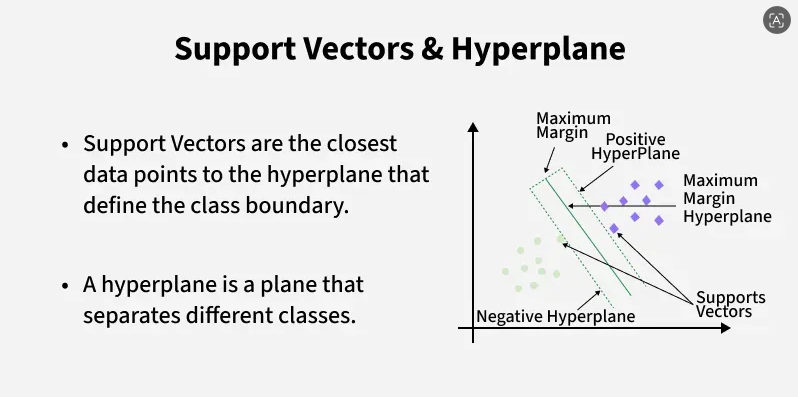
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [30]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

# Upload Iris.csv manually
uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

# Display first 5 rows
df.head()

Saving Iris (1).csv to Iris (1) (2).csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [31]:
# Task 2: Explore the Dataset

# Display shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display class distribution
print("\nClass Distribution:")
print(df["Species"].value_counts())

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.0000

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [32]:
# Task 3: Select Features and Target

# Remove Id column
df = df.drop("Id", axis=1)

# Features
X = df.drop("Species", axis=1)

# Target
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

Feature Shape: (150, 4)
Target Shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [33]:
# Task 4: Split and Scale the Data

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaling completed.")

Training Data: (120, 4)
Testing Data: (30, 4)

Data scaling completed.


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [34]:
# Task 5: Implement Linear SVM

# Create Linear SVM model
svm_model = SVC(
    kernel="linear",
    C=1.0
)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("Linear SVM model trained successfully.")

print("\nPredictions:")
print(y_pred_svm)

Linear SVM model trained successfully.

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Linear SVM Accuracy: 1.0
Linear SVM Accuracy (%): 100.0
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


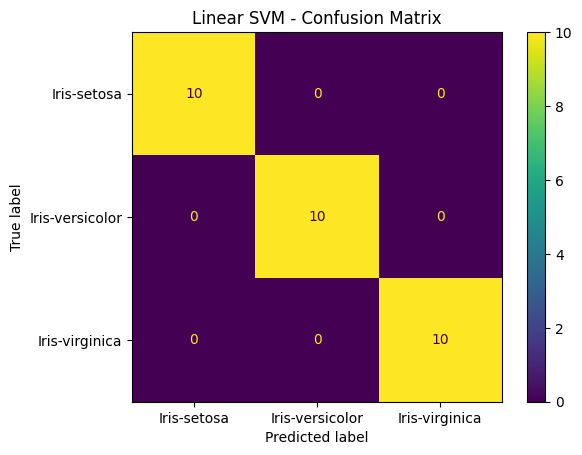

Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [35]:
# Task 6: Accuracy

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Accuracy (%):", svm_accuracy * 100)
# Confusion Matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

# Display confusion matrix graphically
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp.plot()
plt.title("Linear SVM - Confusion Matrix")
plt.show()
# Classification Report

print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
# Classification Report

print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

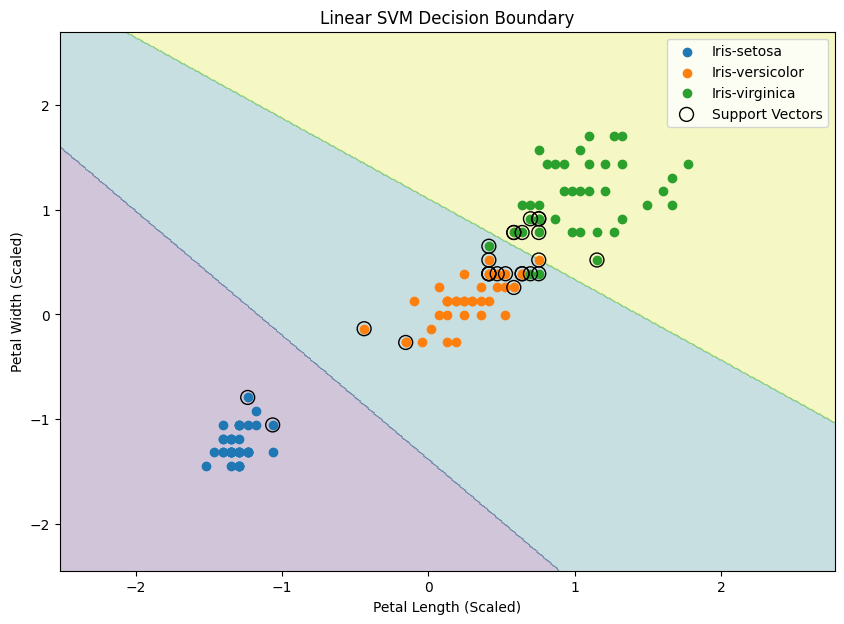

Number of Support Vectors: 25


In [36]:
# Task 7: SVM Decision Boundary

# Select two features
X_2d = df[["PetalLengthCm", "PetalWidthCm"]]
y_2d = df["Species"]

# Split the 2D dataset
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the 2D features
scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

# Train Linear SVM
svm_2d = SVC(
    kernel="linear",
    C=1.0
)

svm_2d.fit(X2_train_scaled, y2_train)

# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict each point in mesh
Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert predictions into numbers
class_names = svm_2d.classes_
Z_num = np.array([
    np.where(class_names == label)[0][0]
    for label in Z
])

Z_num = Z_num.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_num,
    alpha=0.25
)

# Plot data points
for i, species in enumerate(class_names):
    mask = y2_train == species

    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=species
    )

# Highlight support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

print("Number of Support Vectors:",
      len(svm_2d.support_vectors_))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

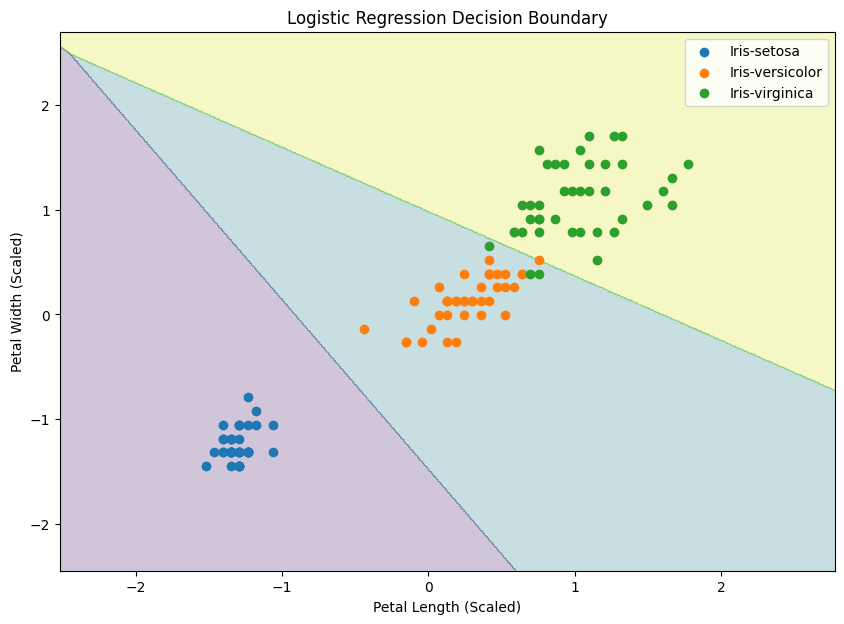

In [37]:
# Task 8: Logistic Regression Decision Boundary

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=200
)

# Train model
logistic_model.fit(X2_train_scaled, y2_train)

# Predictions
y_pred_logistic = logistic_model.predict(X2_test_scaled)

# Create mesh grid
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict mesh points
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert class labels to numbers
Z_logistic_num = np.array([
    np.where(class_names == label)[0][0]
    for label in Z_logistic
])

Z_logistic_num = Z_logistic_num.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_logistic_num,
    alpha=0.25
)

# Plot training points
for species in class_names:
    mask = y2_train == species

    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=species
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

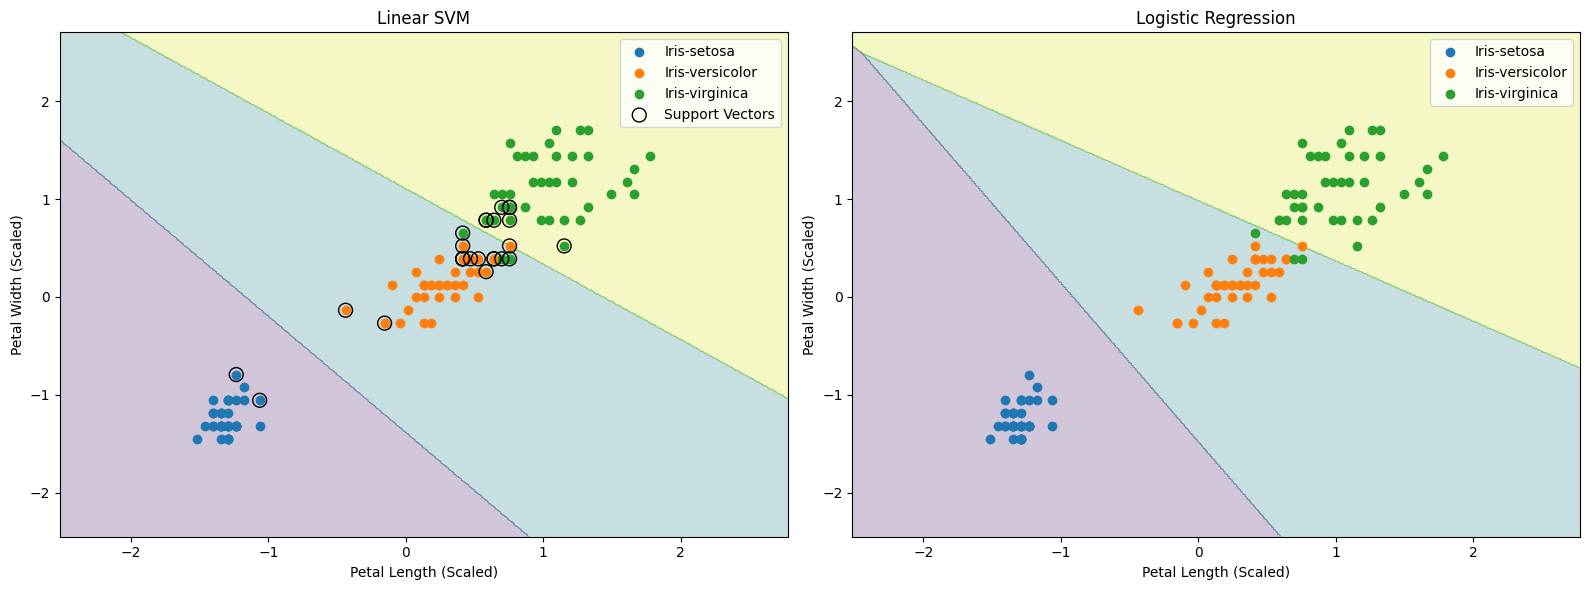

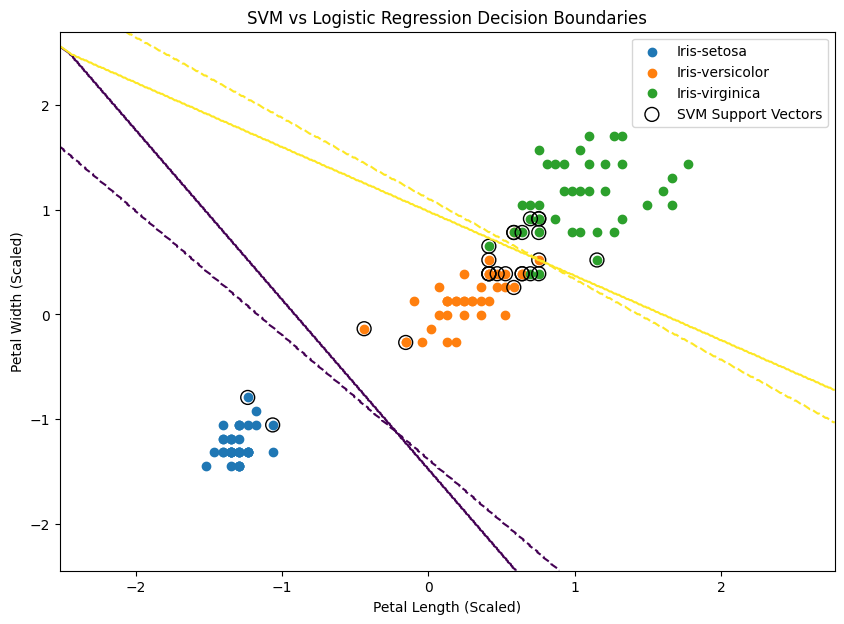

In [38]:
# Task 9: Compare SVM and Logistic Regression Boundaries

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# Linear SVM
# -------------------------

axes[0].contourf(
    xx,
    yy,
    Z_num,
    alpha=0.25
)

for species in class_names:
    mask = y2_train == species

    axes[0].scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=species
    )

# Support vectors
axes[0].scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

axes[0].set_title("Linear SVM")
axes[0].set_xlabel("Petal Length (Scaled)")
axes[0].set_ylabel("Petal Width (Scaled)")
axes[0].legend()


# -------------------------
# Logistic Regression
# -------------------------

axes[1].contourf(
    xx,
    yy,
    Z_logistic_num,
    alpha=0.25
)

for species in class_names:
    mask = y2_train == species

    axes[1].scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=species
    )

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Petal Length (Scaled)")
axes[1].set_ylabel("Petal Width (Scaled)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Compare both classifiers on the same graph

plt.figure(figsize=(10, 7))

# Plot data
for species in class_names:
    mask = y2_train == species

    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=species
    )

# Draw SVM decision boundaries
plt.contour(
    xx,
    yy,
    Z_num,
    levels=[0.5, 1.5],
    linestyles="--"
)

# Draw Logistic Regression boundaries
plt.contour(
    xx,
    yy,
    Z_logistic_num,
    levels=[0.5, 1.5],
    linestyles="-"
)

# Support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="SVM Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM vs Logistic Regression Decision Boundaries")
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [39]:
# Task 10: Compare Performance

# Calculate accuracy
svm_2d_accuracy = accuracy_score(y2_test, svm_2d.predict(X2_test_scaled))
logistic_accuracy = accuracy_score(
    y2_test,
    y_pred_logistic
)

print("=" * 50)
print("PERFORMANCE COMPARISON")
print("=" * 50)

print("\nLinear SVM Accuracy:",
      svm_2d_accuracy)

print("Linear SVM Accuracy (%):",
      svm_2d_accuracy * 100)

print("\nLogistic Regression Accuracy:",
      logistic_accuracy)

print("Logistic Regression Accuracy (%):",
      logistic_accuracy * 100)


# -------------------------
# SVM Confusion Matrix
# -------------------------

print("\n" + "=" * 50)
print("SVM CONFUSION MATRIX")
print("=" * 50)

cm_svm_2d = confusion_matrix(
    y2_test,
    svm_2d.predict(X2_test_scaled)
)

print(cm_svm_2d)

print("\nSVM Classification Report:")
print(
    classification_report(
        y2_test,
        svm_2d.predict(X2_test_scaled)
    )
)


# -------------------------
# Logistic Regression
# -------------------------

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 50)

cm_logistic = confusion_matrix(
    y2_test,
    y_pred_logistic
)

print(cm_logistic)

print("\nLogistic Regression Classification Report:")
print(
    classification_report(
        y2_test,
        y_pred_logistic
    )
)

# Final Accuracy Comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Logistic Regression"
    ],
    "Accuracy": [
        svm_2d_accuracy,
        logistic_accuracy
    ],
    "Accuracy (%)": [
        svm_2d_accuracy * 100,
        logistic_accuracy * 100
    ]
})

print(comparison)

PERFORMANCE COMPARISON

Linear SVM Accuracy: 0.9333333333333333
Linear SVM Accuracy (%): 93.33333333333333

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy (%): 93.33333333333333

SVM CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


LOGISTIC REGRESSION CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virgi

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.